In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , classification_report
import warnings
warnings.filterwarnings("ignore")

Read Data

In [32]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("naeem41/cicids2017-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cicids2017-dataset' dataset.
Path to dataset files: /kaggle/input/cicids2017-dataset


In [33]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/cicids2017-dataset/combinenew.csv


In [34]:
df_data = pd.read_csv("/root/.cache/kagglehub/datasets/naeem41/cicids2017-dataset/versions/1/combinenew.csv")
df_data.shape

(2830744, 79)

Show Data

In [35]:
df_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.00,2.00,0.00,12.00,0.00,6.00,6.00,6.00,0.00,...,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN
1,55054,109.00,1.00,1.00,6.00,6.00,6.00,6.00,6.00,0.00,...,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN
2,55055,52.00,1.00,1.00,6.00,6.00,6.00,6.00,6.00,0.00,...,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN
3,46236,34.00,1.00,1.00,6.00,6.00,6.00,6.00,6.00,0.00,...,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN
4,54863,3.00,2.00,0.00,12.00,0.00,6.00,6.00,6.00,0.00,...,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,BENIGN


Information About Data And Describe Data

In [36]:
df_data.info(show_counts=True)
# Target => Label => Str
# Destination Port => Object
# Remaining Data => Float


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830744 entries, 0 to 2830743
Data columns (total 79 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0    Destination Port             2830744 non-null  object 
 1    Flow Duration                2830743 non-null  float64
 2    Total Fwd Packets            2830743 non-null  float64
 3    Total Backward Packets       2830743 non-null  float64
 4   Total Length of Fwd Packets   2830743 non-null  float64
 5    Total Length of Bwd Packets  2830743 non-null  float64
 6    Fwd Packet Length Max        2830743 non-null  float64
 7    Fwd Packet Length Min        2830743 non-null  float64
 8    Fwd Packet Length Mean       2830743 non-null  float64
 9    Fwd Packet Length Std        2830743 non-null  float64
 10  Bwd Packet Length Max         2830743 non-null  float64
 11   Bwd Packet Length Min        2830743 non-null  float64
 12   Bwd Packet Length Mean     

In [37]:
pd.set_option('display.float_format', lambda x: '%.2f' % x) # So We Can See The Data Clearly.
df_data.describe() # Data Need Scaling

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,...,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00,2830743.00
mean,14785663.93,9.36,10.39,549.30,16162.64,207.60,18.71,58.20,68.91,870.85,...,5.42,-2741.69,81551.32,41134.12,153182.52,58295.82,8316036.63,503843.95,8695751.98,7920031.01
std,33653744.09,749.67,997.39,9993.59,2263088.05,717.18,60.34,186.09,281.19,1946.37,...,636.43,1084989.38,648599.94,393381.52,1025824.97,577092.28,23630078.58,4602984.48,24366888.33,23363418.93
min,-13.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,-536870661.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,155.00,2.00,1.00,12.00,0.00,6.00,0.00,6.00,0.00,0.00,...,0.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,31316.00,2.00,2.00,62.00,123.00,37.00,2.00,34.00,0.00,79.00,...,1.00,24.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,3204828.50,5.00,4.00,187.00,482.00,81.00,36.00,50.00,26.16,280.00,...,2.00,32.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,119999998.00,219759.00,291922.00,12900000.00,655453030.00,24820.00,2325.00,5940.86,7125.60,19530.00,...,213557.00,138.00,110000000.00,74200000.00,110000000.00,110000000.00,120000000.00,76900000.00,120000000.00,120000000.00


Check About Dublicates

In [38]:
df_data.duplicated().sum()

np.int64(330406)

There is 330406 duplicated we will remove

In [39]:
df_data.drop_duplicates(inplace=True) # Drop Duplicates

df_data.duplicated().sum() # Check Again

np.int64(0)

In [40]:
df_data.shape # The Shape Data After Drop Duplicates

(2500338, 79)

Check Null Values

In [41]:
df_data.replace([np.inf, -np.inf], np.nan, inplace=True)
df_data.replace(['?', 'unknown', 'Unknown', 'UNKNOWN', 'None', 'none', ' '], np.nan, inplace=True)
print(df_data.isnull().sum().to_string())

 Destination Port                  0
 Flow Duration                     1
 Total Fwd Packets                 1
 Total Backward Packets            1
Total Length of Fwd Packets        1
 Total Length of Bwd Packets       1
 Fwd Packet Length Max             1
 Fwd Packet Length Min             1
 Fwd Packet Length Mean            1
 Fwd Packet Length Std             1
Bwd Packet Length Max              1
 Bwd Packet Length Min             1
 Bwd Packet Length Mean            1
 Bwd Packet Length Std             1
Flow Bytes/s                    1542
 Flow Packets/s                 1538
 Flow IAT Mean                     1
 Flow IAT Std                      1
 Flow IAT Max                      1
 Flow IAT Min                      1
Fwd IAT Total                      1
 Fwd IAT Mean                      1
 Fwd IAT Std                       1
 Fwd IAT Max                       1
 Fwd IAT Min                       1
Bwd IAT Total                      1
 Bwd IAT Mean                      1
 

Null Values Is Very Low We Will Drop it

In [42]:
df_data.dropna(inplace=True)
# Check
print(df_data.isnull().sum().to_string())

 Destination Port               0
 Flow Duration                  0
 Total Fwd Packets              0
 Total Backward Packets         0
Total Length of Fwd Packets     0
 Total Length of Bwd Packets    0
 Fwd Packet Length Max          0
 Fwd Packet Length Min          0
 Fwd Packet Length Mean         0
 Fwd Packet Length Std          0
Bwd Packet Length Max           0
 Bwd Packet Length Min          0
 Bwd Packet Length Mean         0
 Bwd Packet Length Std          0
Flow Bytes/s                    0
 Flow Packets/s                 0
 Flow IAT Mean                  0
 Flow IAT Std                   0
 Flow IAT Max                   0
 Flow IAT Min                   0
Fwd IAT Total                   0
 Fwd IAT Mean                   0
 Fwd IAT Std                    0
 Fwd IAT Max                    0
 Fwd IAT Min                    0
Bwd IAT Total                   0
 Bwd IAT Mean                   0
 Bwd IAT Std                    0
 Bwd IAT Max                    0
 Bwd IAT Min  

In [43]:
# Destination Port => object , but we want it to be int.
df_data.columns = df_data.columns.str.strip()
df_data['Destination Port'] = pd.to_numeric(df_data['Destination Port'], errors='coerce')
df_data.dropna(subset=['Destination Port'], inplace=True)
df_data['Destination Port'] = df_data['Destination Port'].astype(int)


df_data.reset_index(drop=True, inplace=True)

print(df_data['Destination Port'].dtype)
print("Shape:", df_data.shape)

int64
Shape: (2498796, 79)


Remove Columns ALL Zero's And Data Leakage

In [44]:
df_data.columns = df_data.columns.str.strip()
col_zero = [
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bytes/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bulk Rate",
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "Fwd URG Flags",
    "CWE Flag Count"
]
zero_pct = (df_data[col_zero].replace(0, np.nan).isnull().sum() / len(df_data)) * 100
print(zero_pct)

Fwd Avg Packets/Bulk   100.00
Fwd Avg Bytes/Bulk     100.00
Bwd Avg Packets/Bulk   100.00
Bwd Avg Bytes/Bulk     100.00
Fwd Avg Bulk Rate      100.00
Bwd Avg Bulk Rate      100.00
Bwd PSH Flags          100.00
Bwd URG Flags          100.00
Fwd URG Flags          100.00
CWE Flag Count         100.00
dtype: float64


In [45]:
df_data.drop(columns=col_zero, inplace=True)
print("Shape:", df_data.shape)

Shape: (2498796, 69)


In [46]:
df_data.columns.tolist()

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'URG Flag Count',
 'ECE Flag Count',
 'Down/Up Ratio',
 '

In [47]:
non_negative_cols = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s',
    'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'min_seg_size_forward', 'act_data_pkt_fwd',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min',
    'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]
non_negative_cols = [c for c in non_negative_cols if c in df_data.columns]

bad_row_mask = (df_data[non_negative_cols] < 0).any(axis=1)
bad_row_mask.sum() #number of invalid negative vals in columns

np.int64(2915)

In [48]:
df_data = df_data.loc[~bad_row_mask].reset_index(drop=True)
df_data.shape

(2495881, 69)

Check Class Distribution (Label)

In [49]:
label_counts = df_data['Label'].value_counts()
label_percentage = df_data['Label'].value_counts(normalize=True) * 100

distribution = pd.DataFrame({'Count': label_counts, 'Percentage': label_percentage.round(3)})
print(distribution)

                            Count  Percentage
Label                                        
BENIGN                    2070331       82.95
DoS Hulk                   172688        6.92
DDoS                       127997        5.13
PortScan                    90694        3.63
DoS GoldenEye               10281        0.41
FTP-Patator                  5927        0.24
DoS slowloris                5385        0.22
DoS Slowhttptest             5228        0.21
SSH-Patator                  3217        0.13
Bot                          1948        0.08
Web Attack_Brute Force       1470        0.06
Web Attack_XSS                652        0.03
Infiltration                   35        0.00
Web Attack_Sql Injection       21        0.00
Heartbleed                      7        0.00


The dataset is highly imbalanced (BENIGN dominates)

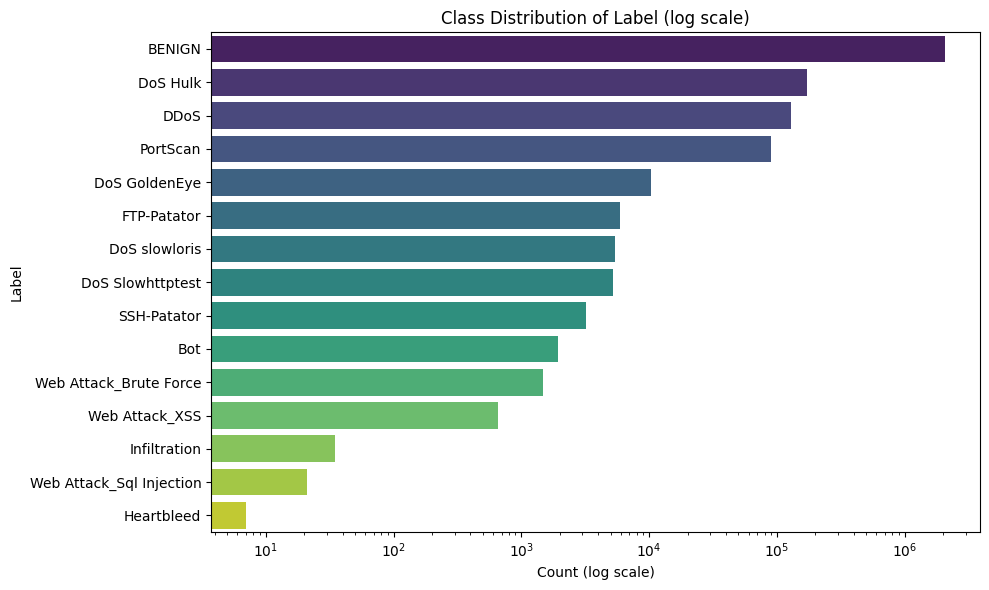

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
plt.xscale('log')
plt.xlabel('Count (log scale)')
plt.ylabel('Label')
plt.title('Class Distribution of Label (log scale)')
plt.tight_layout()
plt.show()

##EDA

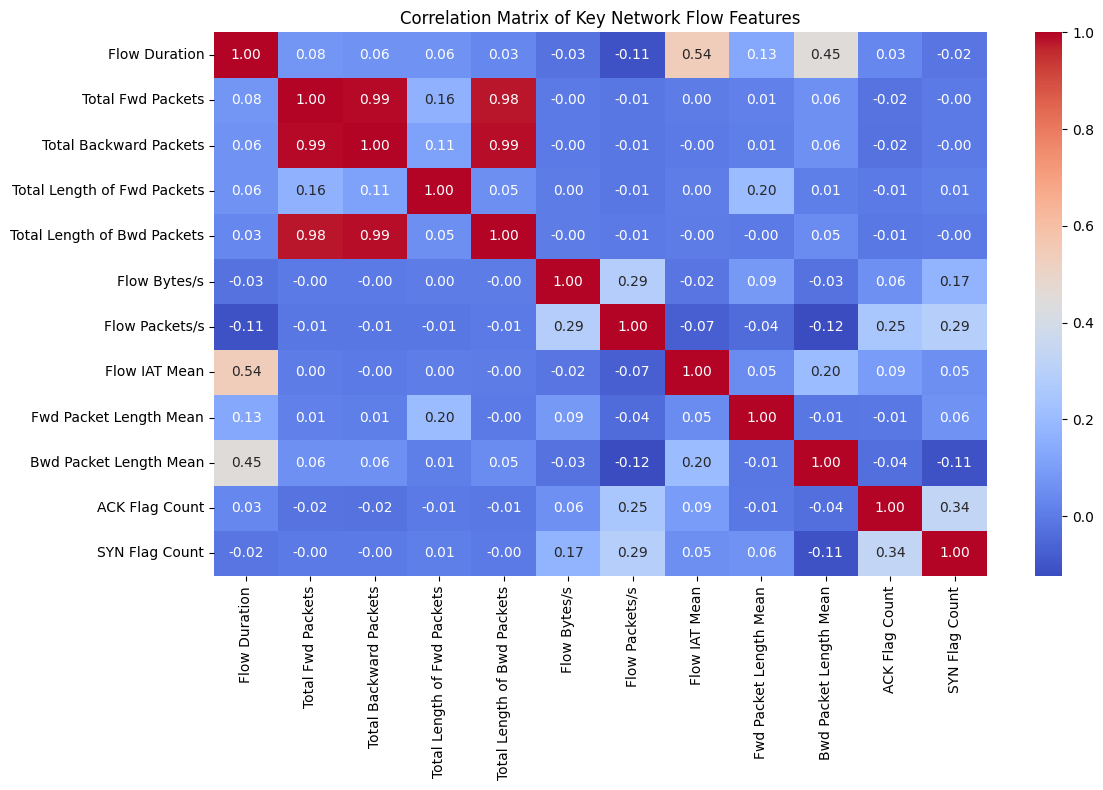

In [51]:
key_cols = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'ACK Flag Count', 'SYN Flag Count'
]

plt.figure(figsize=(12, 8))
corr = df_data[key_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Key Network Flow Features")
plt.tight_layout()
plt.show()

In [52]:
# Delete Columns the corr is very near
cols_to_drop = ['Total Backward Packets', 'Total Length of Bwd Packets']
key_cols = [col for col in key_cols if col not in cols_to_drop]
df_data.drop(columns=cols_to_drop, inplace=True , errors='ignore')
print("Shape:", df_data.shape)

Shape: (2495881, 67)


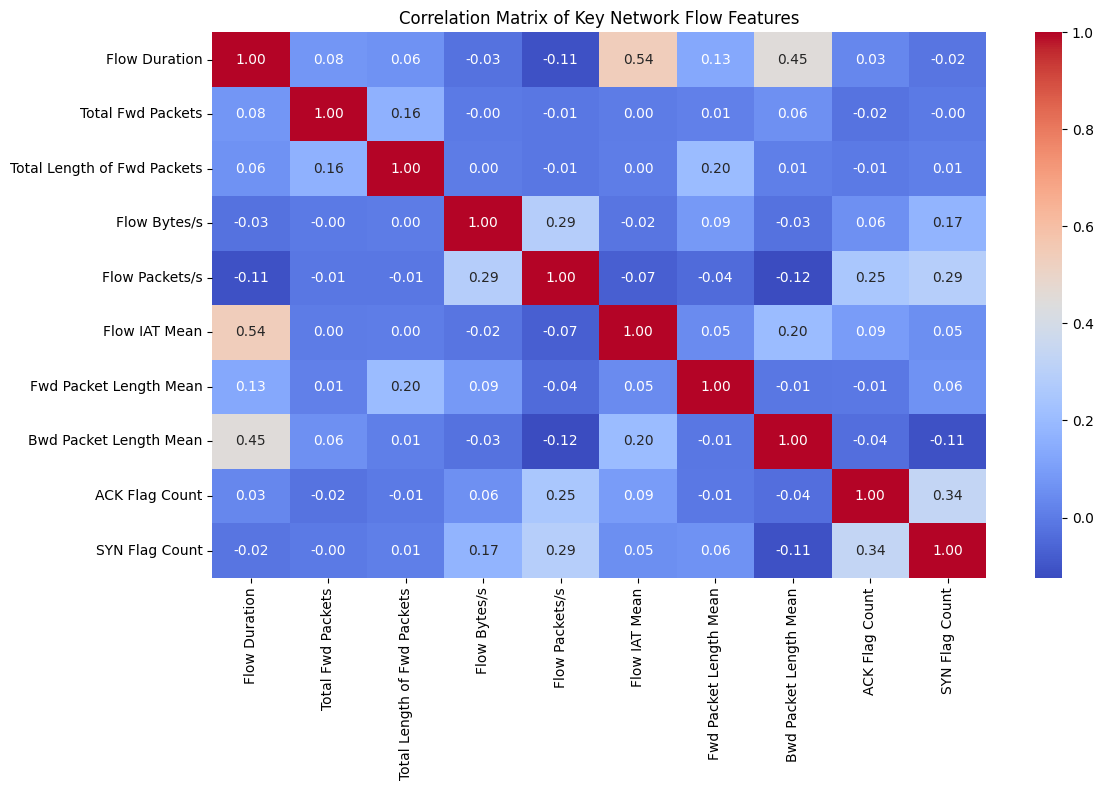

In [53]:
# Check Heatmap Again

plt.figure(figsize=(12, 8))
corr = df_data[key_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Key Network Flow Features")
plt.tight_layout()
plt.show()

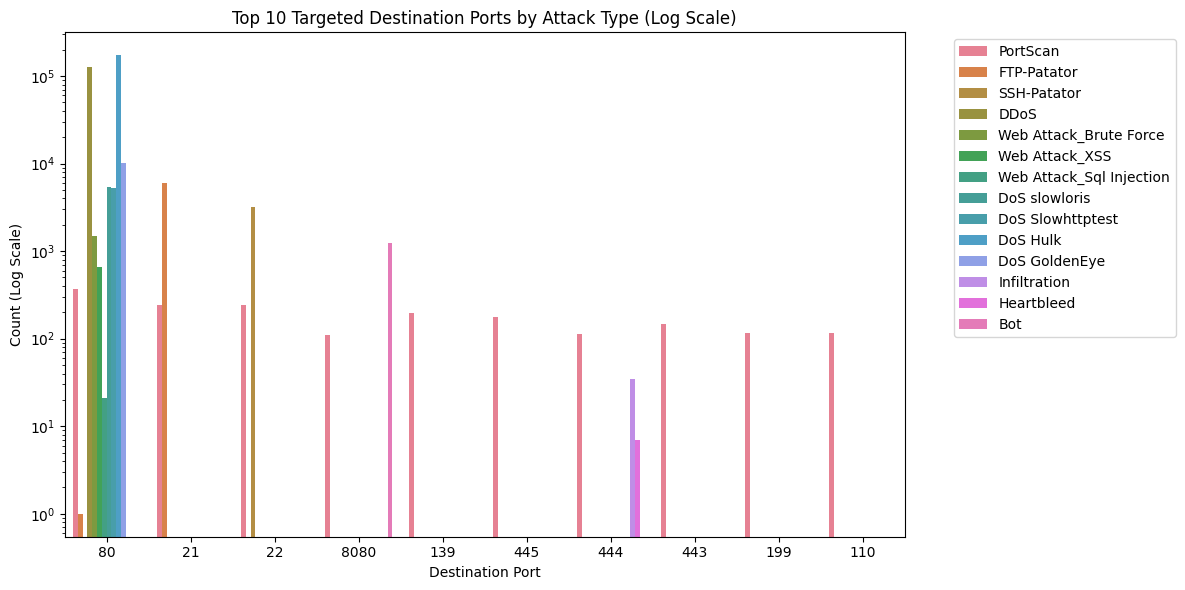

In [54]:
attack_df = df_data[df_data['Label'] != 'BENIGN']
top_ports = attack_df['Destination Port'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.countplot(
    data=attack_df[attack_df['Destination Port'].isin(top_ports)],
    x='Destination Port',
    hue='Label',
    order=top_ports
)
plt.yscale('log')
plt.title('Top 10 Targeted Destination Ports by Attack Type (Log Scale)')
plt.xlabel('Destination Port')
plt.ylabel('Count (Log Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

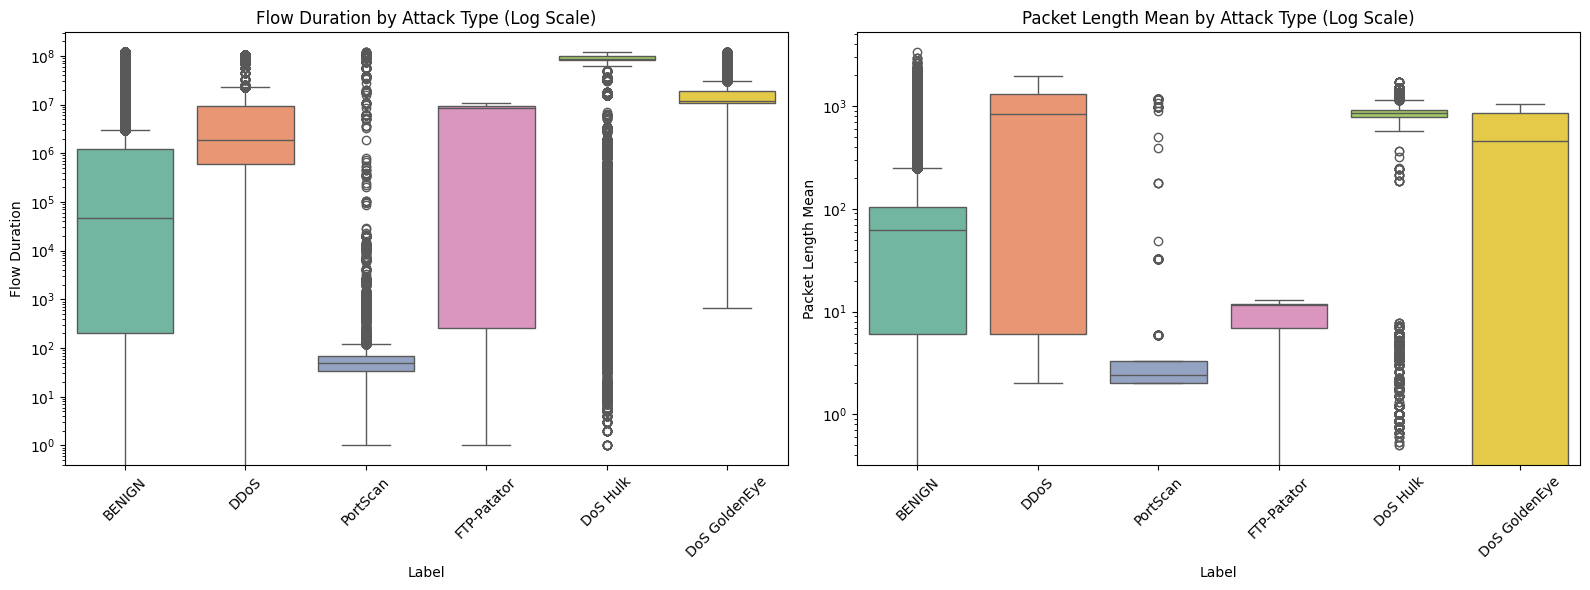

In [55]:
top_labels = df_data['Label'].value_counts().head(6).index
df_subset = df_data[df_data['Label'].isin(top_labels)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=axes[0], data=df_subset, x='Label', y='Flow Duration', palette='Set2')
axes[0].set_yscale('log')
axes[0].set_title('Flow Duration by Attack Type (Log Scale)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(ax=axes[1], data=df_subset, x='Label', y='Packet Length Mean', palette='Set2')
axes[1].set_yscale('log')
axes[1].set_title('Packet Length Mean by Attack Type (Log Scale)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

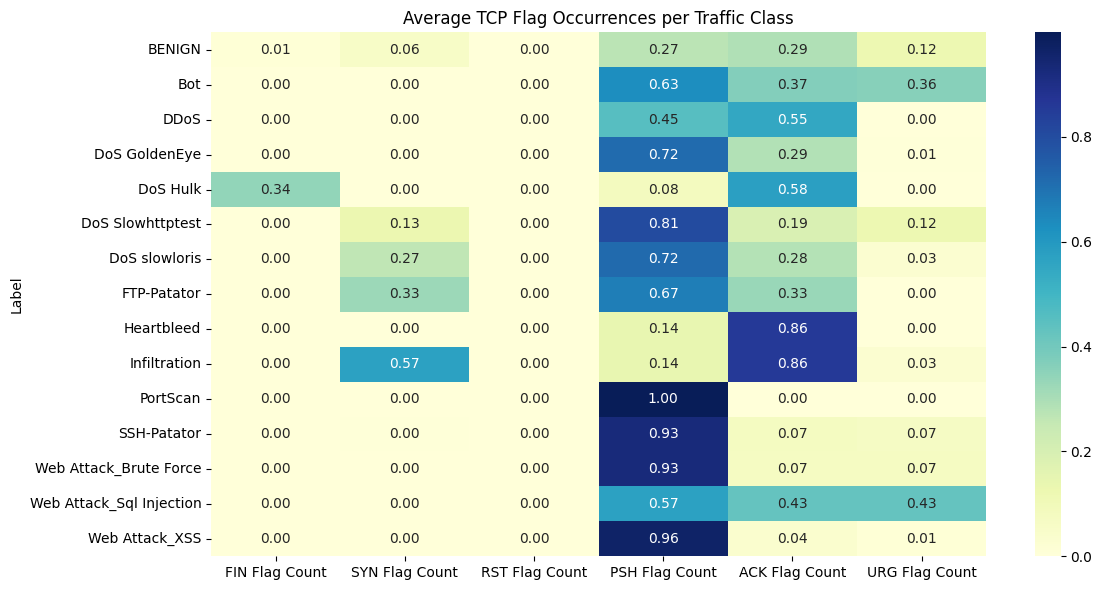

In [56]:
flag_cols = ['FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count']
flag_summary = df_data.groupby('Label')[flag_cols].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(flag_summary, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average TCP Flag Occurrences per Traffic Class")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

making dest ports into categories

In [ ]:
def categorize_port(port):
    if port <= 1023:
        return 'Well_Known'
    elif port <= 49151:
        return 'Registered'
    else:
        return 'Dynamic'

df_data['Port_Category'] = df_data['Destination Port'].apply(categorize_port)
df_data = pd.get_dummies(df_data, columns=['Port_Category'], drop_first=True)
df_data.drop(columns=['Destination Port'], inplace=True)

Encode categorical labels to numeric values

In [ ]:
le = LabelEncoder()
df_data['Label_Encoded'] = le.fit_transform(df_data['Label'])


Map to Binary (0: BENIGN, 1: ATTACK)

In [ ]:
df_data['Binary_Label'] = df_data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_data, x='Binary_Label', palette='Set1')
plt.title('Binary Class Distribution (0: BENIGN, 1: ATTACK)')
plt.xlabel('Traffic Type (0=Benign, 1=Attack)')
plt.ylabel('Count')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(ax=axes[0], data=df_data, x='Binary_Label', y='Flow Duration', palette='Set1')
axes[0].set_yscale('log')
axes[0].set_title('Flow Duration: Benign vs Attack')

sns.boxplot(ax=axes[1], data=df_data, x='Binary_Label', y='Total Fwd Packets', palette='Set1')
axes[1].set_yscale('log')
axes[1].set_title('Total Fwd Packets: Benign vs Attack')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 10))
# dropping string and multi class target to calculate correlation properly
binary_corr = df_data.drop(columns=['Label', 'Label_Encoded']).corr()[['Binary_Label']].sort_values(by='Binary_Label', ascending=False)
sns.heatmap(binary_corr.head(15), annot=True, cmap='Reds', fmt='.3f')
plt.title("Top 15 Features Correlated with Attack Traffic (Binary_Label)")
plt.show()

Feature & Target Split

In [ ]:
X = df_data.drop(columns=['Label', 'Label_Encoded', 'Binary_Label'])
y = df_data['Binary_Label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Feature Scaling
- Fit on train set, transform both train and test to prevent data leakage


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Final Cleaned Data Overview

In [ ]:
print("Final shape:", df_data.shape)
df_data.head()

## Preprocessing

In [ ]:
# # no need to scale dummy(0,1) features
# dummy_cols = [col for col in X.columns if col.startswith('Port_Category_')]
# numeric_cols = [col for col in X.columns if col not in dummy_cols]

# scaler = StandardScaler()

# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

# X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
# X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# print("Train shape:", X_train_scaled.shape)
# print("Test shape:", X_test_scaled.shape)

#### The data is imbalanced (BENIGN dominates), so we compute class weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

#### Try a simple model first (Logistic Regression) to get a baseline we can compare future models against

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

baseline_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

y_pred = baseline_model.predict(X_test_scaled)
y_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

In [ ]:
ConfusionMatrixDisplay.from_estimator(baseline_model, X_test_scaled, y_test, cmap='Blues')
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.show()